Loading pre-trained Glove model(50 dimensions )


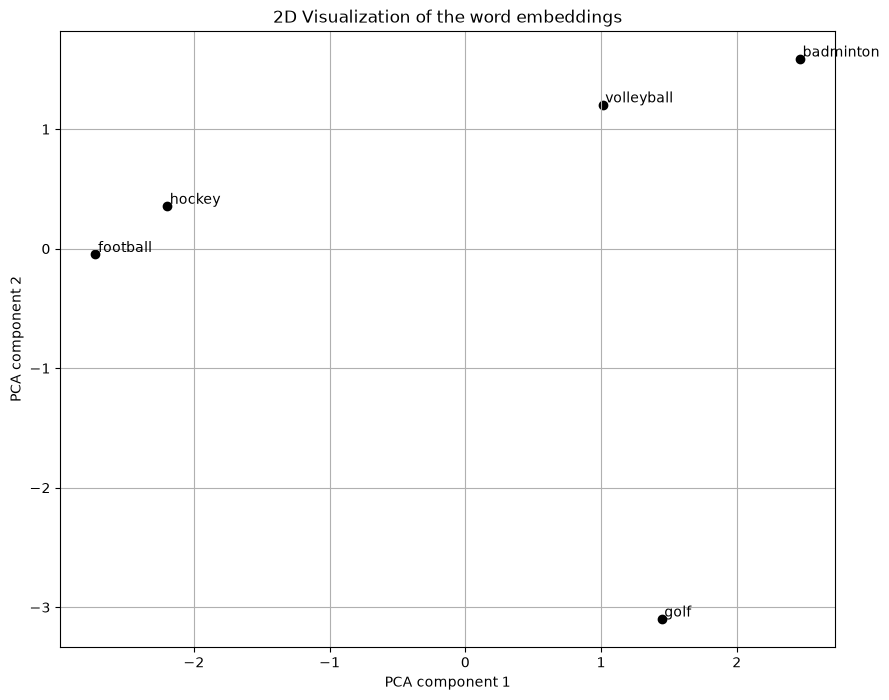


 Top 5 words similar to '{word}':
network(0.7708
interactive(0.7614
format(0.7585
channels(0.7531
networks(0.7529


In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 
from gensim.downloader import load
def reduce_dimensions(embeddings):
    pca =  PCA (n_components = 2)
    reduced_embeddings = pca.fit_transform(embeddings)
    return reduced_embeddings
def visualize_embeddings(words,reduced_embeddings):
    plt.figure(figsize=(10,8))
    for i ,word in enumerate(words):
        x,y = reduced_embeddings[i]
        plt.scatter(x,y,color = 'black',marker ='o')
        plt.text(x+0.02, y+0.02 , word)
    plt.title("2D Visualization of the word embeddings")
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.grid()
    plt.show()
def get_similar_words(word, model):
    print("\n Top 5 words similar to '{word}':")
    similar_words = model.most_similar(word , topn =5)
    for similar_word, similarity in similar_words:
        print(f"{similar_word}({similarity :.4f}")
print ("Loading pre-trained Glove model(50 dimensions )")
model = load("glove-wiki-gigaword-50")
words = ['football', 'volleyball','golf','hockey','badminton',]
embeddings = [model[word]for word in words]
reduced_embeddings = reduce_dimensions(embeddings)
visualize_embeddings(words , reduced_embeddings )
get_similar_words("programming",model)

Enter a word : patient


words similar to 'patient':
1.checked(similarity :0.8512)
2.hospital(similarity :0.7742)
3.treatment(similarity :0.6179)
4.medicine(similarity :0.2080)
5.the(similarity :0.2018)


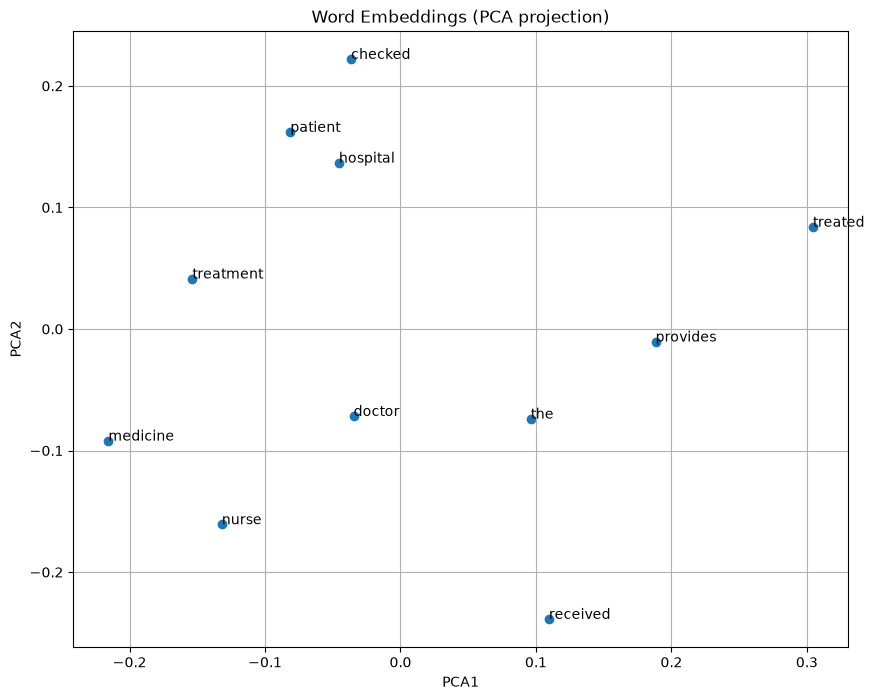

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 
from gensim.models import Word2Vec 
corpus =[ 
    "the doctor treated the patient",
    "the patient received received medicine",
    "the nurse checked the patient",
    "the hospital provides treatment"]
tokenized_corpus =[sentence.lower().split()for sentence in corpus]
model = Word2Vec (sentences = tokenized_corpus ,vector_size =5,window = 2,min_count=1,epochs =5)
word =input ("Enter a word :").lower()
if word in model.wv:
    similar =model.wv.most_similar(word ,topn =5)
    print(f"words similar to '{word}':")
    for i ,(w,score) in enumerate (similar ,1):
        print(f"{i}.{w}(similarity :{score:.4f})")
else:
    print("word not found")
words = list(model.wv.index_to_key)
word_vectors = model.wv[words]
pca =PCA (n_components=2)
result =pca.fit_transform(word_vectors)
plt.figure (figsize =(10,8))
plt.scatter(result[:,0],result[:,1])
for i , word in enumerate(words):
    plt.annotate(word,xy =(result[i,0],result[i,1]))
plt.title("Word Embeddings (PCA projection)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True)
plt.show()
    


